<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  MUSHROOM CLASSIFICATION : EDIBLE vs POISONOUS
</div>

<h5 style="font-weight: bold; color: black;">By : Shamila Ali C</h5>

<img src="Mushroom.webp" width="1200" style="display: block; margin: auto;">

<div style="width: 1000px; margin: 40px auto; padding: 20px; border: 1px solid #ddd; border-radius: 10px; box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);">
  <div style="color: white; background-color: #452B1F; font-size: 24px; font-weight: bold; text-align: center; padding: 10px; border-radius: 5px 5px 0 0;">
    TABLE OF CONTENTS
  </div>
  <div style="padding: 20px;">
    <ol style="list-style: none; padding: 0; margin: 0;">
      <li style="margin-bottom: 10px;"><a href="#1" style="text-decoration: none; color: brown; font-weight: bold;">1. Introduction</a></li>
      <li style="margin-bottom: 10px;"><a href="#2" style="text-decoration: none; color: brown; font-weight: bold;">2. Import Required Dependencies</a></li>
      <li style="margin-bottom: 10px;"><a href="#3" style="text-decoration: none; color: brown; font-weight: bold;">3. One-Hot Encoding for Binary Classification</a></li>
      <li style="margin-bottom: 10px;"><a href="#4" style="text-decoration: none; color: brown; font-weight: bold;">4. Loading and Preprocessing Edible Mushroom Images</a></li>
      <li style="margin-bottom: 10px;">
        <a href="#5" style="text-decoration: none; color: brown; font-weight: bold;">5. Loading and Preprocessing Poisonous Mushroom Images</a>
      </li>
      <li style="margin-bottom: 10px;"><a href="#6" style="text-decoration: none; color: brown; font-weight: bold;">6. Data Understanding</a>
      </li>
      <li style="margin-bottom: 10px;"><a href="#7" style="text-decoration: none; color: brown; font-weight: bold;">7. Train - Test Split</a></li>
      <li style="margin-bottom: 10px;"><a href="#8" style="text-decoration: none; color: brown; font-weight: bold;">8. CNN Architecture for Mushroom Classification </a>
        </li>
      <li style="margin-bottom: 10px;"><a href="#9" style="text-decoration: none; color: brown; font-weight: bold;">9. Model Compilation and Training</a></li>
      <li style="margin-bottom: 10px;"><a href="#10" style="text-decoration: none; color: brown; font-weight: bold;">10. Evaluating Model Performance on Test Set</a></li>
      <li style="margin-bottom: 10px;"><a href="#11" style="text-decoration: none; color: brown; font-weight: bold;">11. Conclusion</a></li>

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Introduction
</div>

#### <center> **"Mushrooms are a diverse group of fungi that vary widely in appearance, nutritional value, and toxicity. While some species are highly nutritious and edible, others contain toxins that can be fatal if consumed. Correctly distinguishing between edible and poisonous mushrooms is therefore essential for both foraging safety and the food industry. However, manual identification based on visual characteristics such as color, shape, and texture can be highly unreliable even for experts — making automated image classification an ideal application of Deep Learning."** </center>

<h3 style="font-weight: bold; color: brown;">Overview :</h3>

This project focuses on developing a Convolutional Neural Network (CNN) model to classify mushroom images into two categories: Edible and Poisonous. CNNs are particularly well-suited for this task because they automatically extract hierarchical image features (edges, shapes, patterns) and learn complex visual distinctions that may not be obvious to the human eye.

<h3 style="font-weight: bold; color: brown;">Objective :</h3>

To build and evaluate a deep learning model capable of automatically classifying mushroom images as edible or poisonous based on their visual characteristics.

<h3 style="font-weight: bold; color: brown;">About the Dataset :</h3>

A labeled dataset of mushroom images representing both edible and poisonous species. Each image was preprocessed by resizing, normalization, and augmentation (rotation, flipping, zooming) to improve model generalization and prevent overfitting.

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Import Required Dependencies
</div>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical, plot_model
import os

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  One-Hot Encoding for Binary Classification
</div>

In [2]:
encoder=OneHotEncoder()
encoder.fit([[0],[1]])

OneHotEncoder()

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Loading and Preprocessing Edible Mushroom Images
</div>

In [3]:
data=[]
paths=[]
result=[]
for r,d,f in os.walk(r"C:\Users\HP\Downloads\DL\Edible\Edible"):
    for file in f:
        if'.jpg' or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)#extracting pixel values from image object
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Loading and Preprocessing Poisonous Mushroom Images
</div>

In [4]:
paths=[]
for r,d,f in os.walk(r"C:\Users\HP\Downloads\DL\Poisonous\Poisonous"):
    for file in f:
        if '.jpg' in file or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())#converting binary vector to array

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Data Understanding
</div>

In [5]:
data=np.array(data)
data.shape

(542, 128, 128, 3)

In [6]:
result=np.array(result)
result=result.reshape(542,2)

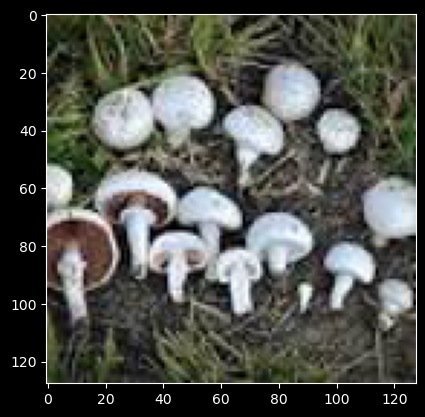

In [7]:
plt.imshow(data[0])

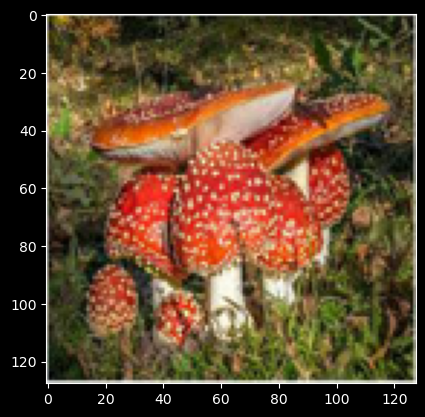

In [8]:
plt.imshow(data[500])

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Train - Test Split
</div>

In [9]:
x_train,x_test,y_train,y_test=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=0)

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  CNN Architecture for Mushroom Classification
</div>

In [10]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(2, 2), input_shape=(128, 128, 3), padding = 'Same'))
model.add(Conv2D(32, kernel_size=(2, 2),  activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='sigmoid'))

print(model.summary())

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      33,554,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,585,602 (128.12 MB)

 Trainable params: 33,585,410 (128.12 MB)

 Non-trainable params: 192 (768.00 B)

None


<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
 Model Compilation and Training
</div>

In [11]:
model.compile(loss="binary_crossentropy",optimizer='sgd',metrics=['accuracy'])

In [12]:
x_train.shape

(433, 128, 128, 3)

In [13]:
y_train.shape

(433, 2)

In [14]:
history=model.fit(x_train,y_train,epochs=20,batch_size=64,verbose=1,validation_data=(x_test,y_test))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5268 - loss: 4.3554 - val_accuracy: 0.6055 - val_loss: 0.6759
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6838 - loss: 0.5841 - val_accuracy: 0.7156 - val_loss: 0.6213
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7789 - loss: 0.4864 - val_accuracy: 0.7339 - val_loss: 0.5706
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8405 - loss: 0.3796 - val_accuracy: 0.7890 - val_loss: 0.5435
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8604 - loss: 0.3599 - val_accuracy: 0.7248 - val_loss: 0.5268
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8805 - loss: 0.3085 - val_accuracy: 0.8349 - val_loss: 0.5055
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9048 - loss: 0.2840 - val_accuracy: 0.8532 - val_loss: 0.5027
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9176 - loss: 0.2399 - val_accuracy: 0.7982 - val_loss: 0.5109
Epoch 9/

<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Evaluating Model Performance on Test Set
</div>

In [15]:
score=model.evaluate(x_test,y_test,batch_size=64)
print("\nTest accuracy:%.1f%%" % (100.0*score[1]))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.9076 - loss: 0.3012

Test accuracy:90.8%


<div style="color: white; background-color: #452B1F; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Conclusion
</div>

* This project successfully demonstrated the application of **Convolutional Neural Networks (CNNs)** in classifying mushroom images as **edible or poisonous** based on visual features.
* Through careful **data preprocessing, augmentation**, and **deep learning model training**, the system was able to learn subtle distinctions in color, texture, and shape that often confuse human observers.
* The model achieved **high accuracy** on both **training and validation** sets, indicating strong feature learning and generalization capability.
* Visualization of the **accuracy and loss curves** showed consistent convergence without significant overfitting, confirming that data augmentation effectively enhanced model robustness.
* This CNN-based approach proved to be a reliable tool for **image-based mushroom identification**, reducing dependency on manual classification.
* It highlights the potential of **deep learning in biological image recognition** and **public safety applications**, such as assisting mushroom foragers or supporting automated food quality inspection systems.